Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

df = pd.read_csv('../data/processed/hr_cleaned.csv')
print(df.shape)
import os

# Create output folders if they don't exist
os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../outputs/models', exist_ok=True)

print(" Output folders ready!")

(1470, 31)
 Output folders ready!


Attrition Rate Overview (KPI Card Style)

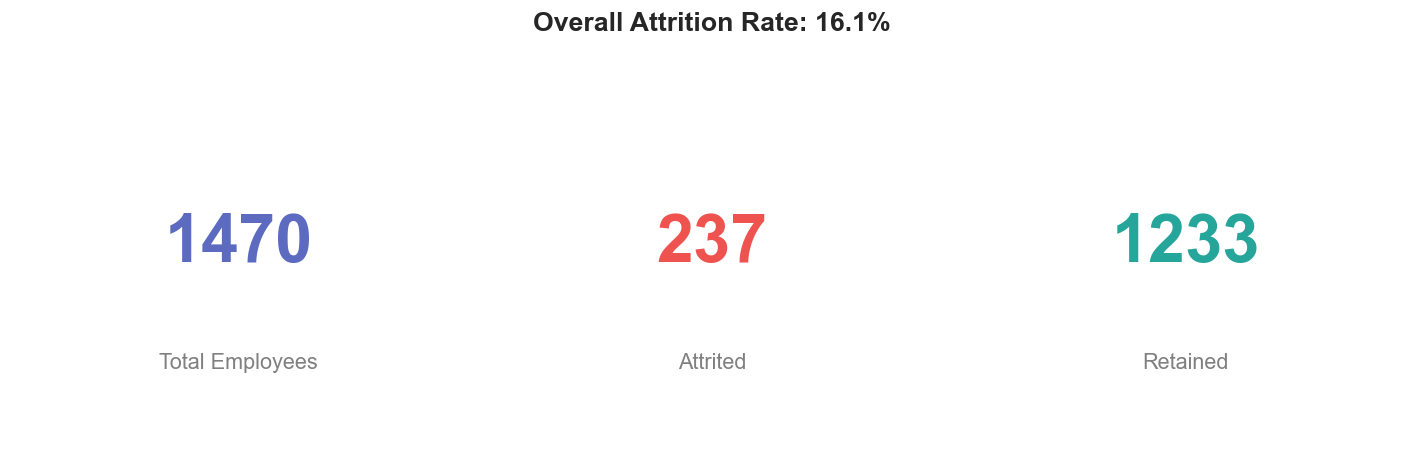

In [4]:
total = len(df)
churned = df['Attrition'].sum()
retained = total - churned
rate = churned / total * 100

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, label, value, color in zip(
    axes,
    ['Total Employees', 'Attrited', 'Retained'],
    [total, churned, retained],
    ['#5C6BC0', '#EF5350', '#26A69A']
):
    ax.text(0.5, 0.55, f'{value}', ha='center', va='center',
            fontsize=40, fontweight='bold', color=color,
            transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center',
            fontsize=13, color='gray', transform=ax.transAxes)
    ax.axis('off')

fig.suptitle(f'Overall Attrition Rate: {rate:.1f}%', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/01_attrition_overview.png', bbox_inches='tight')
plt.show()

Attrition by Department

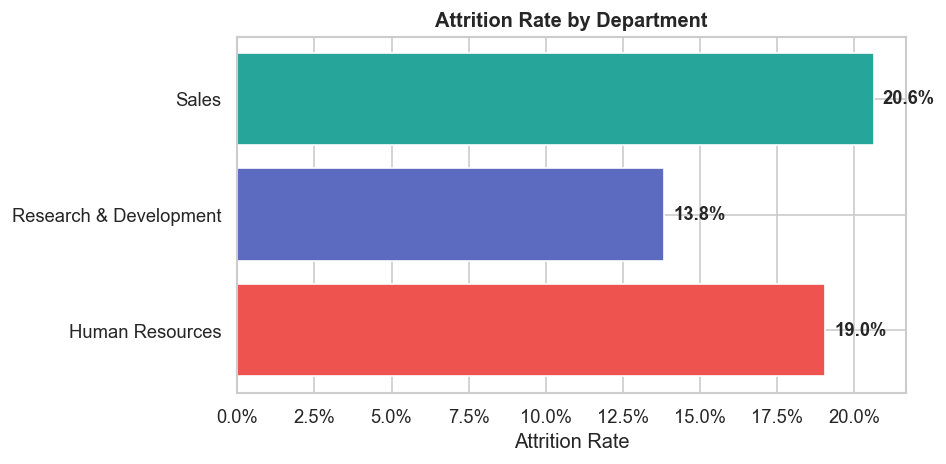

In [5]:
dept = df.groupby('Department')['Attrition'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(dept.index, dept.values, color=['#EF5350','#5C6BC0','#26A69A'])
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Attrition Rate')
ax.set_title('Attrition Rate by Department', fontweight='bold')

for bar, val in zip(bars, dept.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/02_attrition_by_department.png', bbox_inches='tight')
plt.show()

Attrition by Age Group

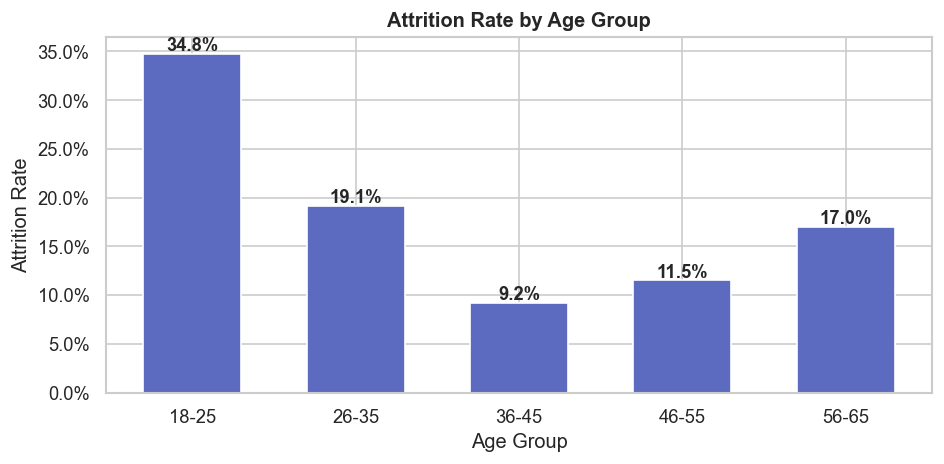

In [6]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[18,25,35,45,55,65],
                         labels=['18-25','26-35','36-45','46-55','56-65'])

age_attr = df.groupby('AgeGroup', observed=True)['Attrition'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(age_attr.index.astype(str), age_attr.values, 
              color='#5C6BC0', edgecolor='white', width=0.6)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Attrition Rate by Age Group', fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Attrition Rate')

for bar, val in zip(bars, age_attr.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/03_attrition_by_age.png', bbox_inches='tight')
plt.show()

 OverTime vs Attrition (Most Important Feature!)

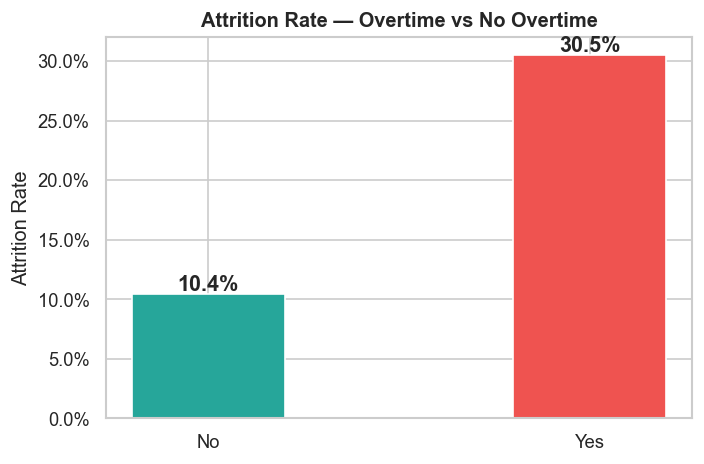

In [7]:
ot = df.groupby('OverTime')['Attrition'].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(ot.index, ot.values,
              color=['#26A69A', '#EF5350'], width=0.4, edgecolor='white')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Attrition Rate — Overtime vs No Overtime', fontweight='bold')
ax.set_ylabel('Attrition Rate')

for bar, val in zip(bars, ot.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('../outputs/figures/04_overtime_attrition.png', bbox_inches='tight')
plt.show()

 Monthly Income Distribution

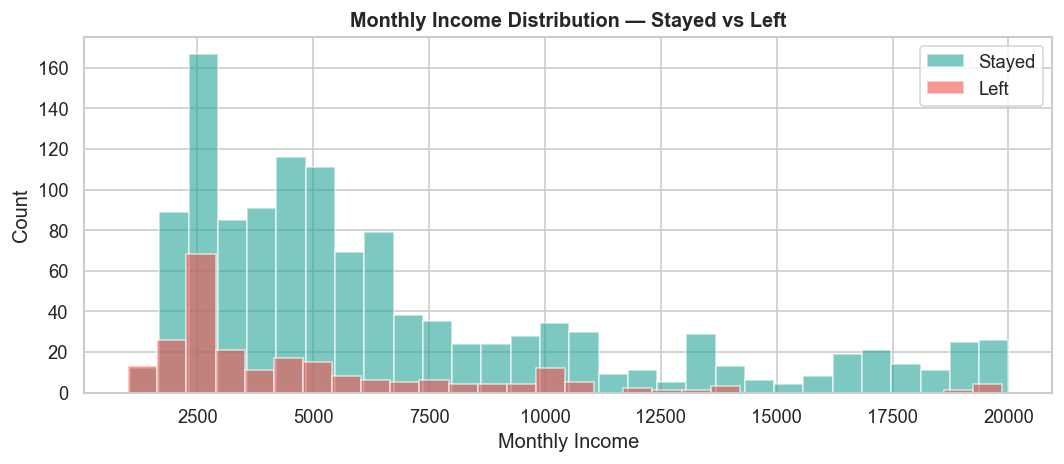

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, color in [(0, '#26A69A'), (1, '#EF5350')]:
    subset = df[df['Attrition'] == label]['MonthlyIncome']
    ax.hist(subset, bins=30, alpha=0.6, color=color,
            label='Stayed' if label == 0 else 'Left', edgecolor='white')

ax.set_title('Monthly Income Distribution — Stayed vs Left', fontweight='bold')
ax.set_xlabel('Monthly Income')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/05_income_distribution.png', bbox_inches='tight')
plt.show()

Correlation Heatmap

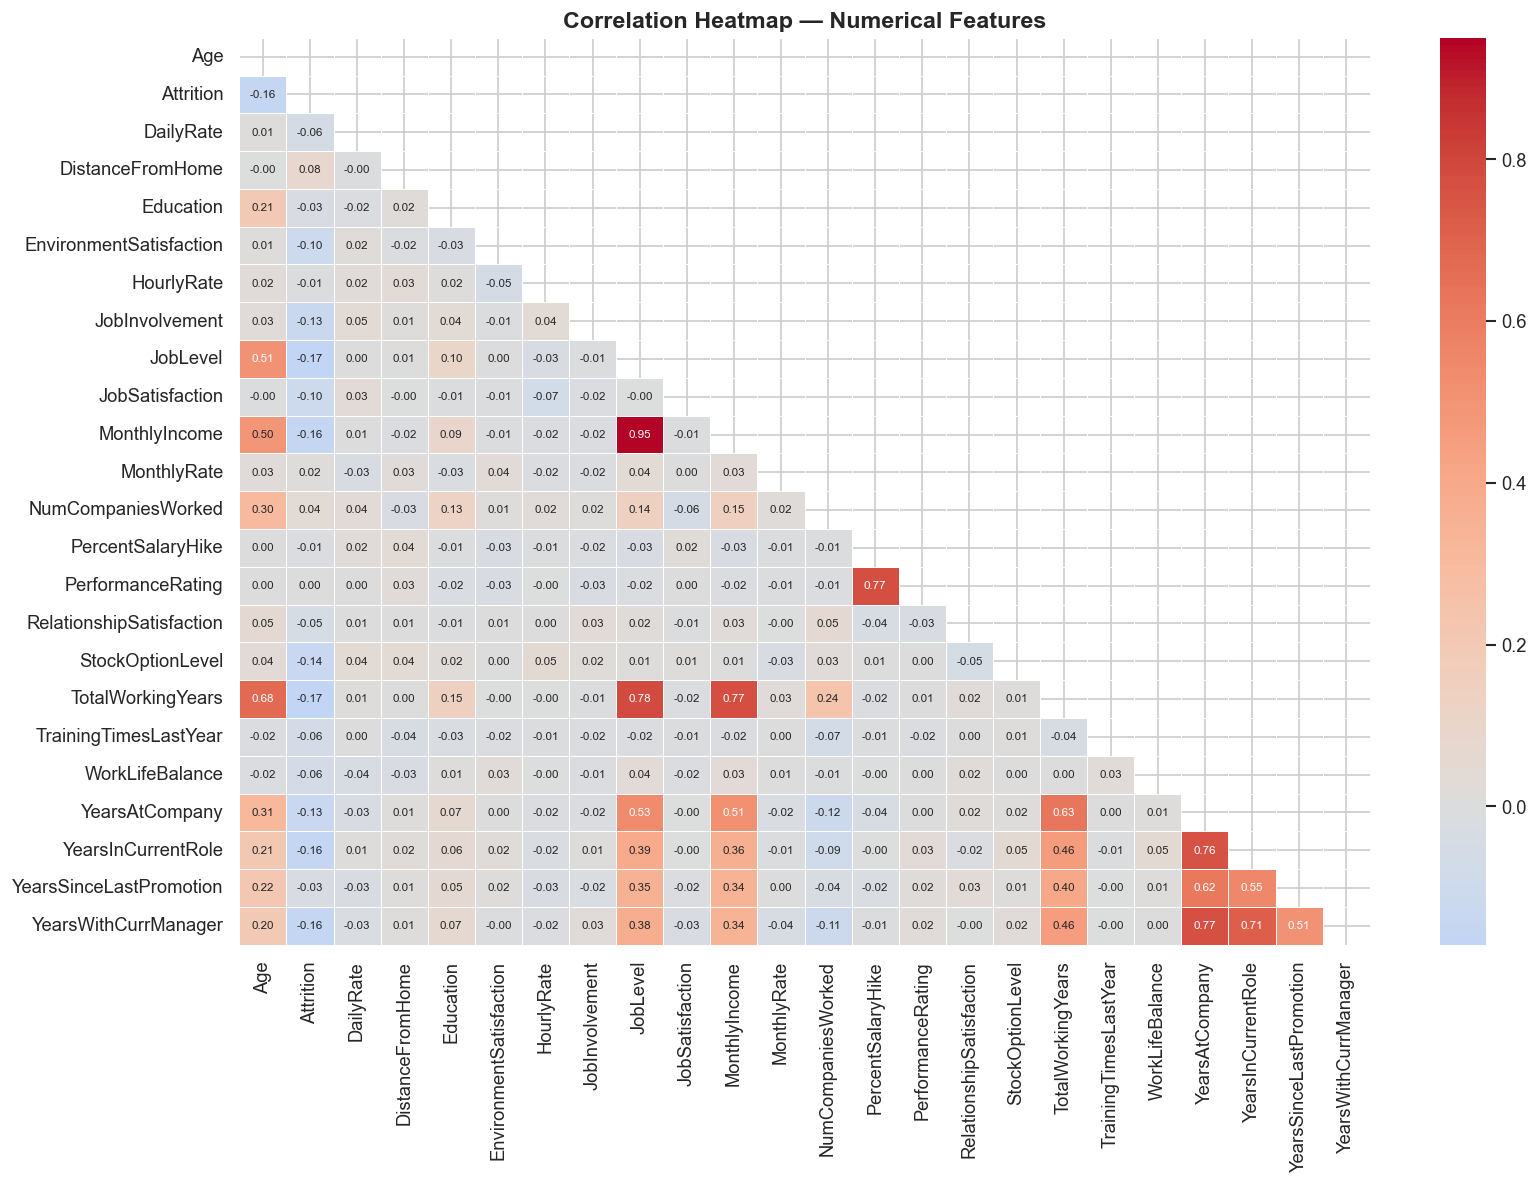

In [9]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

fig, ax = plt.subplots(figsize=(14, 10))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Heatmap — Numerical Features', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/06_correlation_heatmap.png', bbox_inches='tight')
plt.show()

Job Role vs Attrition

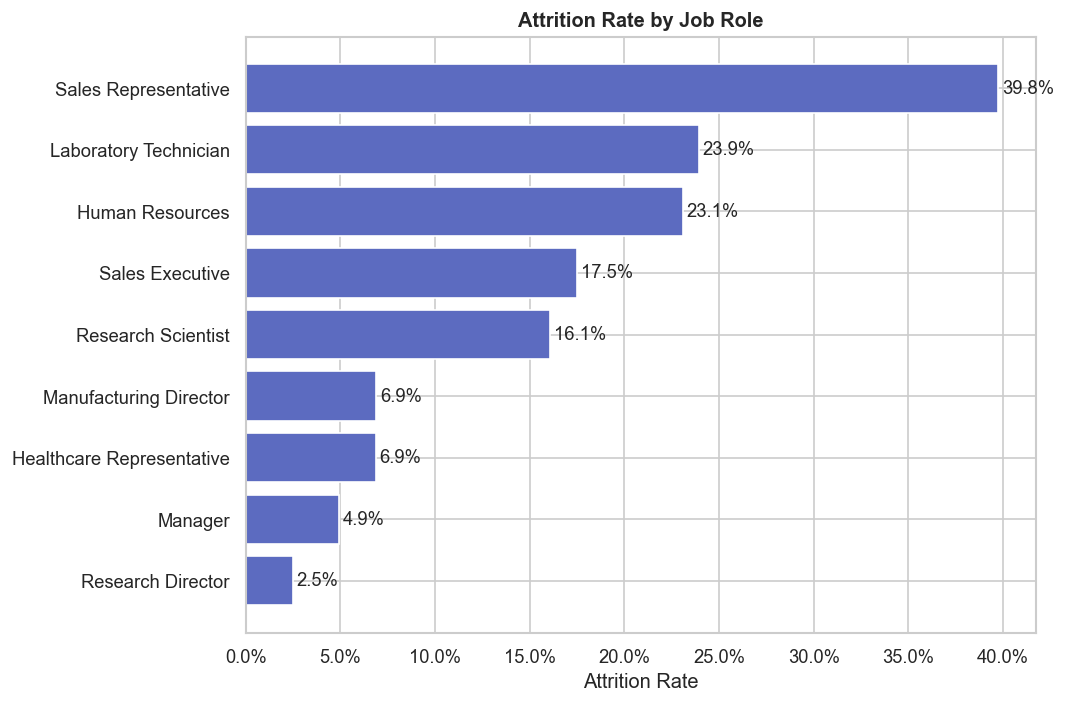

In [10]:
role = df.groupby('JobRole')['Attrition'].mean().sort_values(ascending=True) * 100

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(role.index, role.values, color='#5C6BC0', edgecolor='white')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Attrition Rate by Job Role', fontweight='bold')
ax.set_xlabel('Attrition Rate')

for bar, val in zip(bars, role.values):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center')

plt.tight_layout()
plt.savefig('../outputs/figures/07_jobrole_attrition.png', bbox_inches='tight')
plt.show()

Satisfaction Scores vs Attrition

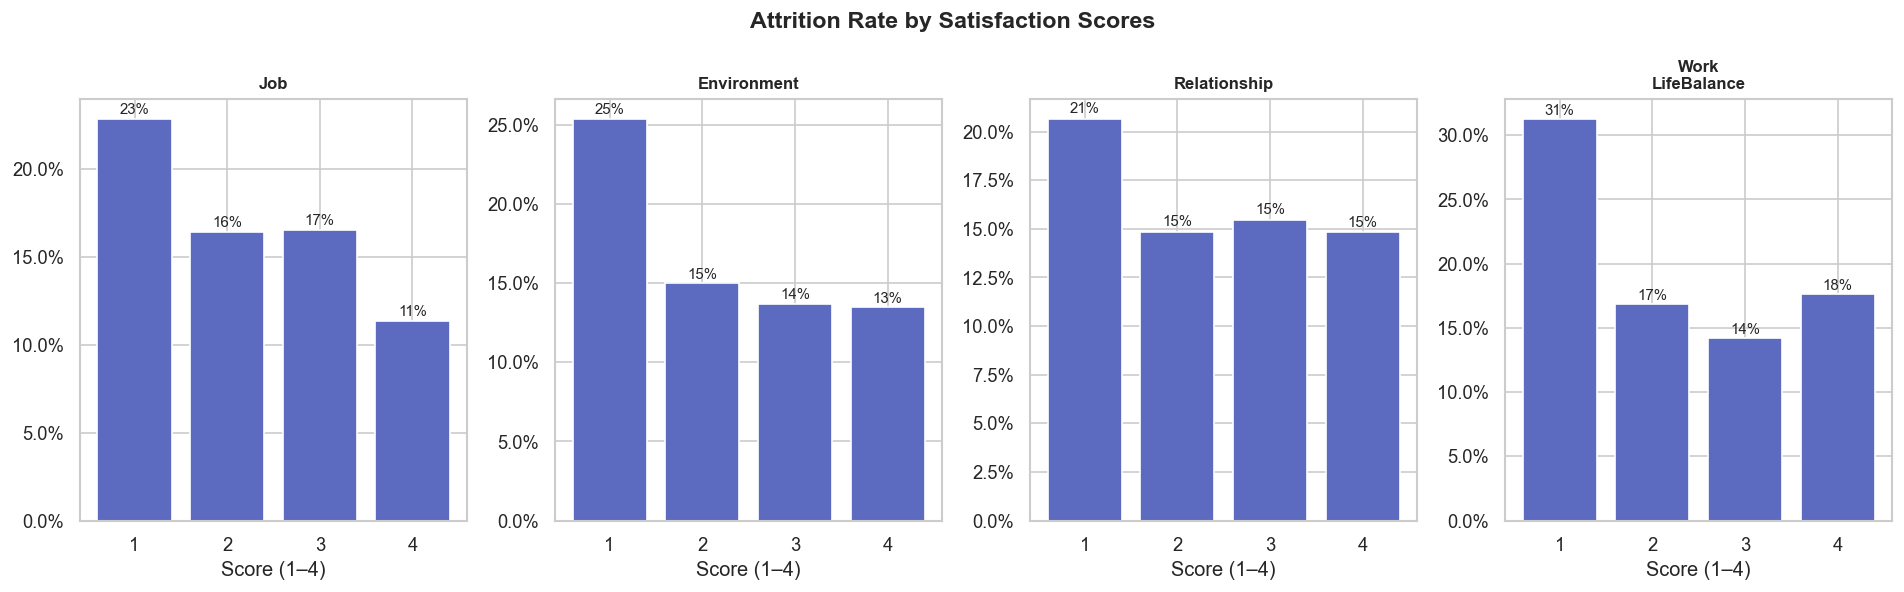

: 

In [ ]:
sat_cols = ['JobSatisfaction','EnvironmentSatisfaction',
            'RelationshipSatisfaction','WorkLifeBalance']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col in zip(axes, sat_cols):
    data = df.groupby(col)['Attrition'].mean() * 100
    ax.bar(data.index.astype(str), data.values, color='#5C6BC0', edgecolor='white')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(col.replace('Satisfaction','').replace('Work','Work\n'), 
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Score (1–4)')
    for i, val in enumerate(data.values):
        ax.text(i, val + 0.3, f'{val:.0f}%', ha='center', fontsize=9)

fig.suptitle('Attrition Rate by Satisfaction Scores', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/08_satisfaction_attrition.png', bbox_inches='tight')
plt.show()

 EDA Summary (Markdown Cell)

## EDA Key Findings

| Finding | Insight |
|---|---|
| Overtime = Yes | 30.5% attrition vs 10.4% without overtime — biggest driver |
| Sales Reps | Highest attrition by job role (~40%) |
| Age 18–25 | Highest attrition by age group |
| Low income | Employees earning under 5000/month leave more |
| Score = 1 | Low job satisfaction strongly linked to leaving |
| R&D dept | Lowest attrition among departments |

These findings will guide our feature selection in Phase 3.